# RFscorer Beginner Tutorial (English)

This notebook walks through the basic workflow of `rfscorer`:

1. Load the package
2. Load the behavior history
3. Split the behavior history into training and test data
4. Split the training data into an observation data and a ground truth data
5. Build the empirical (emp) model (`fit`) and visualize the empirical product-choice probabilities
6. Build the monotonic (mono) model (`optimize(kind="mono")`) and visualize the optimized product-choice probabilities
7. Build the monotonic-convex-concave (mcc) model (`optimize(kind="mcc")`) and visualize the optimized product-choice probabilities
8. Use `transform()` to assign product-choice probabilities and recommendation ranks
9. Evaluate prediction accuracy (`evaluate()`) and produce the recommendation report
10. Save and load the model (`save()` / `load()` / `save_zip()` / `load_zip()`)

## 1. Load the package
First, import the required packages.
`RecencyFrequencyScorer` is the class that performs RF scoring, and `split_by_date` is a utility function that splits a dataset into an observation period and a ground truth period.

In [1]:
import pandas as pd

from rfscorer import RecencyFrequencyScorer, split_by_date

## 2. Load the behavior history
Next, load the behavior history and rename the columns to the default column names (`user_col='user'`, `item_col='item'`, `time_col='datetime'`).
Each row of the behavior history represents a record of a user interacting with (viewing) an item, and the same user is assumed to view the same item multiple times.

> `access_log.csv` is taken from [ohmsha/PyOptBook](https://github.com/ohmsha/PyOptBook/tree/main/7.recommendation)
> (MIT License)

In [2]:
url = "https://raw.githubusercontent.com/ohmsha/PyOptBook/main/7.recommendation/access_log.csv"
df = pd.read_csv(url)
df.columns = ["user", "item", "datetime"]

print("record num:", len(df))
print("user num:", len(df.user.unique()))
print("item num:", len(df.item.unique()))
df.head()

record num: 325908
user num: 31443
item num: 87611


,user,item,datetime
0,4,205587,2015-07-04
1,4,748683,2015-07-04
2,4,790055,2015-07-04
3,4,790055,2015-07-04
4,4,764638,2015-07-04


## 3. Split into training and test data

In this tutorial, we use a hash-based split to divide users into training data (80%) and test data (20%).

In [3]:
df_train = df[df.user.map(lambda x: hash(x) % 10 < 8)]
df_test = df[df.user.map(lambda x: hash(x) % 10 >= 8)]

print("train record num:", len(df_train), "/ user num:", len(df_train.user.unique()))
print("test  record num: ", len(df_test), "/ user num: ", len(df_test.user.unique()))

train record num: 264272 / user num: 25316
test  record num:  61636 / user num:  6127


## 4. Split the training data into an observation data and a ground truth data
Split the training data into an observation period (on or before `target_date`, 28 days by default) and a ground truth period (starting the day after `target_date`, 7 days by default) to produce the observation data and the ground truth data.

In [4]:
target_date = "2015-07-07"
df_train_obs, df_train_gt = split_by_date(df_train, target_date)

## 5. Build the empirical (emp) model (`fit`) and visualize the empirical product-choice probabilities

Build the model by passing the observation data and the ground truth data to `fit()`.
Recency and frequency are computed from the observation data, and the empirical product-choice probabilities are calculated by counting target events (revisits, purchases, conversions, etc.) recorded in the ground truth data.

In [5]:
scorer = RecencyFrequencyScorer()
scorer.fit(df_train_obs, df_train_gt)
scorer.show()

=== profiling ===
record_num: 264272
record_num_obs: 232157
record_num_gt: 32115
observation: 735780 -> 735786
ground_truth: 735787 -> 735787
recency_limit: 7
frequency_limit: 8
target_record_num: 165833 -> 165134
total_cv: 1783 -> 1712
emp_probability_table_:
frequency      1      2      3      4      5      6      7      8
recency                                                          
1          0.014  0.041  0.081  0.052  0.132  0.134  0.163  0.157
2          0.006  0.023  0.027  0.048  0.072  0.083  0.049  0.122
3          0.006  0.023  0.038  0.064  0.044  0.052  0.041  0.068
4          0.005  0.015  0.023  0.042  0.042  0.027  0.011  0.019
5          0.004  0.017  0.025  0.015  0.027  0.030  0.039  0.026
6          0.004  0.011  0.029  0.023  0.005  0.021  0.031  0.000
7          0.005  0.009  0.012  0.025  0.012  0.027  0.000  0.000


Next, plot the empirical product-choice probabilities as a 3D wireframe.
Recency increases along the x-axis (1 = most recent), and frequency increases along the y-axis.

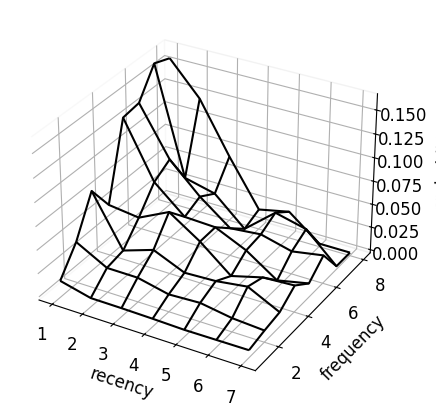

In [6]:
fig_emp = scorer.plot_probability_surface(kind="emp")

## 6. Build the monotonic (mono) model (`optimize(kind="mono")`) and visualize the optimized product-choice probabilities

`kind='mono'` enforces that the product-choice probabilities are monotonically decreasing in recency (Recency constraint) and monotonically increasing in frequency (Frequency constraint).

=== show solve info ===
kind: mono
eps: 0.0
status: optimal
objective_value: 0.7913
elapsed_time: 0.04[s]
num_variables: 56
num_constraints: 209


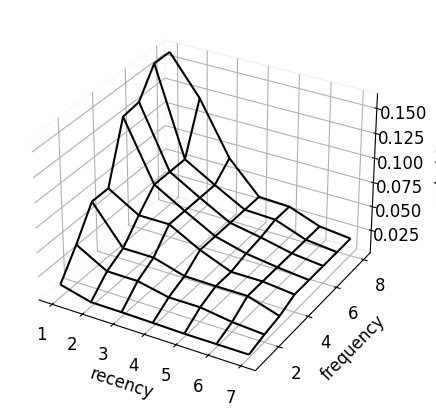

In [7]:
scorer.optimize(kind="mono")
fig_mono = scorer.plot_probability_surface(kind="mono")

## 7. Build the monotonic-convex-concave (mcc) model (`optimize(kind="mcc")`) and visualize the optimized product-choice probabilities

`kind='mcc'` additionally imposes Recency convexity and Frequency concavity, producing a smoother 3D wireframe.

=== show solve info ===
kind: mcc
eps: 0.0
status: optimal
objective_value: 1.8429
elapsed_time: 0.07[s]
num_variables: 56
num_constraints: 291


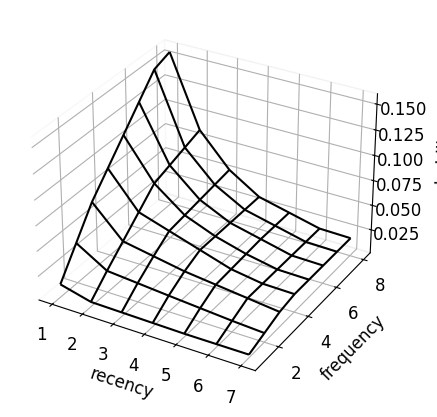

In [8]:
scorer.optimize(kind="mcc")
fig_mcc = scorer.plot_probability_surface(kind="mcc")

## 8. Assign product-choice probabilities and recommendation ranks via `transform()`

Before assigning recommendation scores, split the test data into an observation data and a ground truth data based on `target_date`.
`transform()` assigns the recency, frequency, product-choice probability, and recommendation rank (relative to `target_date`) to each user-item pair.
Within each user, the resulting DataFrame is sorted by `probability` in descending order, and `order` represents the recommendation rank.

In [10]:
df_test_obs, df_test_gt = split_by_date(df_test, target_date)

# Prediction using the mcc model (the mono and emp models can also be specified)
df_rec = scorer.transform(df_test_obs, target_date, kind="mcc")
df_rec.head(10)

,user,item,recency,frequency,probability,order
9190,100099,311656,4,1,0.005005,1
9191,100099,411961,4,1,0.005005,2
9192,100129,353070,5,4,0.024996,1
9196,100138,591186,6,4,0.020066,1
9193,100138,852831,6,3,0.020066,2
9194,100138,1111746,6,2,0.012395,3
9197,100138,81286,2,1,0.006113,4
9198,100138,587992,2,1,0.006113,5
9199,100138,686685,2,1,0.006113,6
9200,100138,328892,2,1,0.006113,7


## 9. Evaluate prediction accuracy (`evaluate()`) and produce the recommendation report

Pass the recommendation DataFrame and the ground truth data derived from the test data to `evaluate()`.
At each recommendation rank cutoff, evaluation metrics such as precision (`precision`), recall (`recall`), and F1 (`f1`) are reported.

In addition, `recall_norm` is the recall normalized to 1.0 at the maximum achievable hits within `df_rec` — i.e., when all items each user interacted with during the observation period are recommended. `f1_norm` is the F1 computed from `precision` and　`recall_norm`.  

In [11]:
scorer.evaluate(df_rec, df_test_gt, order=5)

,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,5547,104,0.018749,0.018009,0.018371,0.280323,0.035147
1,2,10583,166,0.015686,0.028745,0.020296,0.447439,0.030309
2,3,14336,209,0.014579,0.036190,0.020785,0.563342,0.028422
3,4,17322,240,0.013855,0.041558,0.020782,0.646900,0.027129
4,5,19742,261,0.013221,0.045195,0.020457,0.703504,0.025953
5,195,38828,371,0.009555,0.064242,0.016636,1.000000,0.018929


## 10. Save and load the model

The model built with `fit()` and `optimize()` lives in the scorer instance.
By calling `save()`, you can persist it to a file and later restore it with `load()` — no retraining needed.
This is especially useful for server deployment where retraining costs should be avoided.

### Pickle format (`.pkl`) — for server deployment

The lightest-weight format. Calling with no arguments saves `rfscorer.pkl` in the current directory.

In [ ]:
# Save the model (saves rfscorer.pkl in the current directory)
scorer.save()

# Load and verify
scorer_loaded = RecencyFrequencyScorer.load("rfscorer.pkl")
scorer_loaded.predict(1, 1, kind="mcc")

### Zip archive format (`.zip`) — for sharing and artifact management

`save_zip()` creates a zip archive that bundles the pickle with probability-table CSVs and plot PNGs.
Calling with no arguments saves `scorer.zip` in the current directory.
Extracting the zip gives you `rfscorer.pkl`, `metadata.json`, `probabilities/`, and `plots/` — making the model contents directly inspectable.

In [ ]:
# Save as a zip archive (saves scorer.zip in the current directory)
scorer.save_zip()

# Load from the zip and verify
scorer_loaded_zip = RecencyFrequencyScorer.load_zip("scorer.zip")
scorer_loaded_zip.predict(1, 1, kind="mcc")

### Using Google Colab

With no arguments (`path=None`), the files are saved to the current directory (`/content/`). This works as-is, but **files are lost when the runtime resets**.
To persist files across sessions, mount Google Drive and specify a path:

```python
from google.colab import drive
drive.mount("/content/drive")

scorer.save("/content/drive/MyDrive/rfscorer.pkl")
scorer.save_zip("/content/drive/MyDrive/scorer.zip")
```